# Generate Synthetic Measurements from Ground Truth

This notebook generates synthetic syndrome measurements using ground truth Pauli error parameters.

**Input files:**
- `measurements.pkl` - Original measurements (to extract paths and shot counts)
- `graph.pkl` - Network graph
- `ground_truth.pkl` - Ground truth Pauli error rates per edge

**Output:**
- `synthetic_measurements.pkl` - Synthetic measurements generated from ground truth

In [1]:
import pickle
import sys
from pathlib import Path
import numpy as np
sys.path.append("..")

import pandas as pd

In [2]:
# ============================================================
# CONFIGURATION - Update these paths
# ============================================================

DATA_DIR = Path('../syndrome_data_513_2x3/')  # Input directory

MEASUREMENTS_FILE = DATA_DIR / 'measurements.pkl'
GRAPH_FILE = DATA_DIR / 'graph.pkl'
GROUND_TRUTH_FILE = DATA_DIR / 'ground_truth.pkl'

# Output file
OUTPUT_FILE = DATA_DIR / 'synthetic_measurements.pkl'

# Number of shots for synthetic measurements (set to None to use original)
NUM_SHOTS = None  # Will use original measurement shot counts if None

# Verify input files exist
print("Checking input files:")
for f in [MEASUREMENTS_FILE, GRAPH_FILE, GROUND_TRUTH_FILE]:
    status = "✓" if f.exists() else "✗"
    print(f"  {status} {f.name}: {f.exists()}")

Checking input files:
  ✓ measurements.pkl: True
  ✓ graph.pkl: True
  ✓ ground_truth.pkl: True


In [3]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts for [[5,1,3]] code.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [4]:
# ============================================================
# LOAD INPUT FILES
# ============================================================

with open(MEASUREMENTS_FILE, 'rb') as f:
    measurements = pickle.load(f)

with open(GRAPH_FILE, 'rb') as f:
    graph = pickle.load(f)

with open(GROUND_TRUTH_FILE, 'rb') as f:
    ground_truth = pickle.load(f)

# Normalize ground truth format
ground_truth_normalized = {}
for edge, rates in ground_truth.items():
    if isinstance(rates, list):
        ground_truth_normalized[edge] = {
            'px': rates[0], 'py': rates[1], 'pz': rates[2], 
            'pi': 1.0 - sum(rates)
        }
    else:
        ground_truth_normalized[edge] = rates

print(f"Loaded {len(measurements)} original measurements")
print(f"Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
print(f"Loaded Ground Truth for {len(ground_truth_normalized)} edges")

# Display ground truth parameters
print("\nGround Truth Parameters:")
for edge, rates in ground_truth_normalized.items():
    total_err = rates['px'] + rates['py'] + rates['pz']
    print(f"  {edge}: px={rates['px']:.5f}, py={rates['py']:.5f}, pz={rates['pz']:.5f}, total={total_err:.5f}")

Loaded 24 original measurements
Loaded graph with 6 nodes and 7 edges
Loaded Ground Truth for 7 edges

Ground Truth Parameters:
  (0, 1): px=0.00452, py=0.00720, pz=0.00647, total=0.01819
  (0, 3): px=0.00464, py=0.00293, pz=0.00659, total=0.01416
  (1, 2): px=0.00562, py=0.00781, pz=0.00757, total=0.02100
  (1, 4): px=0.00598, py=0.00623, pz=0.00598, total=0.01819
  (2, 5): px=0.01270, py=0.01416, pz=0.01978, total=0.04663
  (3, 4): px=0.00354, py=0.00720, pz=0.00696, total=0.01770
  (4, 5): px=0.01611, py=0.01685, pz=0.01318, total=0.04614


In [5]:
# ============================================================
# [[5,1,3]] SYNDROME COMPUTATION FUNCTIONS
# ============================================================

from typing import List, Tuple, Dict

# [[5,1,3]] stabilizers
STABILIZERS_513 = [
    "XZZXI",  # S1
    "IXZZX",  # S2
    "XIXZZ",  # S3
    "ZXIXZ",  # S4
]

def anticommutes(pauli1: str, pauli2: str) -> bool:
    """Check if two single-qubit Paulis anticommute."""
    if pauli1 == 'I' or pauli2 == 'I':
        return False
    if pauli1 == pauli2:
        return False
    return True


def compute_syndrome_513(error_type: str, qubit: int) -> int:
    """Compute the 4-bit syndrome for a single-qubit Pauli error."""
    if error_type == 'I':
        return 0
    
    syndrome = 0
    for stab_idx, stabilizer in enumerate(STABILIZERS_513):
        stab_pauli = stabilizer[qubit]
        if anticommutes(error_type, stab_pauli):
            syndrome |= (1 << stab_idx)
    return syndrome


# Build syndrome lookup table
SYNDROME_TABLE_513 = {}
for error in ['I', 'X', 'Y', 'Z']:
    for qubit in range(5):
        syndrome = compute_syndrome_513(error, qubit)
        SYNDROME_TABLE_513[(error, qubit)] = syndrome


def pauli_compose(state: np.ndarray, edge_probs: np.ndarray) -> np.ndarray:
    """
    Compose accumulated Pauli state with edge's Pauli channel.
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution
        edge_probs: [pX, pY, pZ] edge error probabilities
    
    Returns:
        New [pI, pX, pY, pZ] state after applying edge channel
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    e_px, e_py, e_pz = edge_probs[0], edge_probs[1], edge_probs[2]
    e_pi = 1.0 - e_px - e_py - e_pz
    
    new_pi = pi*e_pi + px*e_px + py*e_py + pz*e_pz
    new_px = pi*e_px + px*e_pi + py*e_pz + pz*e_py
    new_py = pi*e_py + py*e_pi + px*e_pz + pz*e_px
    new_pz = pi*e_pz + pz*e_pi + px*e_py + py*e_px
    
    return np.array([new_pi, new_px, new_py, new_pz])


def get_edge_pauli_probs(edge: Tuple[int, int], params: Dict) -> np.ndarray:
    """Get Pauli error probabilities [px, py, pz] for an edge."""
    edge_key = tuple(sorted(edge))
    edge_data = params.get(edge_key)
    
    if edge_data is None:
        raise KeyError(f"No parameters for edge {edge_key}")
    
    return np.array([edge_data['px'], edge_data['py'], edge_data['pz']])


def pauli_to_syndrome_513_exact(state: np.ndarray) -> np.ndarray:
    """
    Exact computation of syndrome distribution for [[5,1,3]] code.
    Enumerates all 4^5 = 1024 possible error configurations.
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    pauli_probs = {'I': pi, 'X': px, 'Y': py, 'Z': pz}
    paulis = ['I', 'X', 'Y', 'Z']
    
    syndrome_probs = np.zeros(16)
    
    for e0 in paulis:
        for e1 in paulis:
            for e2 in paulis:
                for e3 in paulis:
                    for e4 in paulis:
                        prob = pauli_probs[e0] * pauli_probs[e1] * pauli_probs[e2] * pauli_probs[e3] * pauli_probs[e4]
                        syndrome = 0
                        for q, e in enumerate([e0, e1, e2, e3, e4]):
                            syndrome ^= SYNDROME_TABLE_513[(e, q)]
                        syndrome_probs[syndrome] += prob
    
    return syndrome_probs


def predict_syndrome_513(path_edges: List[Tuple[int, int]],
                         params: Dict,
                         num_shots: int = 4096) -> np.ndarray:
    """
    Predict syndrome histogram for [[5,1,3]] code using Pauli channel composition.
    
    Args:
        path_edges: List of edge tuples in the path
        params: Dict mapping edge -> {px, py, pz, pi}
        num_shots: Number of shots for histogram scaling
    
    Returns:
        Predicted histogram (16 elements)
    """
    # Start with identity (no error)
    state = np.array([1.0, 0.0, 0.0, 0.0])  # [pI, pX, pY, pZ]
    
    # Compose Pauli channels for each edge
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, params)
        state = pauli_compose(state, edge_probs)
    
    # Convert to syndrome distribution
    syndrome_probs = pauli_to_syndrome_513_exact(state)
    
    # Scale to histogram counts
    histogram = syndrome_probs * num_shots
    
    return histogram.astype(np.float32)


print("Syndrome computation functions defined.")

Syndrome computation functions defined.


In [6]:
# ============================================================
# GENERATE SYNTHETIC MEASUREMENTS
# ============================================================

synthetic_measurements = []

for i, original_measurement in enumerate(measurements):
    path_edges = original_measurement.path_edges
    
    # Get shot count from original or use configured value
    if NUM_SHOTS is None:
        shots = int(np.sum(original_measurement.histogram))
    else:
        shots = NUM_SHOTS
    
    # Generate synthetic histogram using ground truth
    synthetic_histogram = predict_syndrome_513(
        path_edges=path_edges,
        params=ground_truth_normalized,
        num_shots=shots
    )
    
    # Create synthetic measurement with same metadata
    synthetic_measurement = TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=synthetic_histogram,
        duration=original_measurement.duration,
        latency_stats=original_measurement.latency_stats,
        code_type=original_measurement.code_type
    )
    
    synthetic_measurements.append(synthetic_measurement)
    
    # Print progress
    synthetic_probs = synthetic_histogram / np.sum(synthetic_histogram)
    print(f"[{i+1}/{len(measurements)}] Path {path_edges}: P(0000)={synthetic_probs[0]:.4f}")

print(f"\nGenerated {len(synthetic_measurements)} synthetic measurements.")

[1/24] Path [(0, 3), (3, 4), (4, 1)]: P(0000)=0.7782
[2/24] Path [(0, 1), (1, 2)]: P(0000)=0.8211
[3/24] Path [(0, 1), (1, 4), (4, 3)]: P(0000)=0.7627
[4/24] Path [(0, 1), (1, 4)]: P(0000)=0.8328
[5/24] Path [(0, 3), (3, 4)]: P(0000)=0.8520
[6/24] Path [(0, 1), (1, 2), (2, 5)]: P(0000)=0.6493
[7/24] Path [(0, 1), (1, 4), (4, 5)]: P(0000)=0.6600
[8/24] Path [(0, 3), (3, 4), (4, 5)]: P(0000)=0.6749
[9/24] Path [(1, 4), (4, 5), (5, 2)]: P(0000)=0.5724
[10/24] Path [(1, 0), (0, 3)]: P(0000)=0.8499
[11/24] Path [(1, 4), (4, 3)]: P(0000)=0.8349
[12/24] Path [(1, 0), (0, 3), (3, 4)]: P(0000)=0.7782
[13/24] Path [(1, 2), (2, 5), (5, 4)]: P(0000)=0.5646
[14/24] Path [(1, 2), (2, 5)]: P(0000)=0.7099
[15/24] Path [(1, 4), (4, 5)]: P(0000)=0.7217
[16/24] Path [(2, 1), (1, 0), (0, 3)]: P(0000)=0.7654
[17/24] Path [(2, 1), (1, 4), (4, 3)]: P(0000)=0.7520
[18/24] Path [(2, 5), (5, 4), (4, 3)]: P(0000)=0.5738
[19/24] Path [(2, 1), (1, 4)]: P(0000)=0.8211
[20/24] Path [(2, 5), (5, 4)]: P(0000)=0.6250
[

In [7]:
# ============================================================
# COMPARE SYNTHETIC VS ORIGINAL
# ============================================================

SYNDROME_LABELS = [format(i, '04b') for i in range(16)]

comparison_data = []
for orig, synth in zip(measurements, synthetic_measurements):
    orig_probs = orig.histogram / np.sum(orig.histogram)
    synth_probs = synth.histogram / np.sum(synth.histogram)
    
    tvd = 0.5 * np.sum(np.abs(orig_probs - synth_probs))
    
    comparison_data.append({
        'Path': str(orig.path_edges),
        'Hops': len(orig.path_edges),
        'Orig P(0000)': orig_probs[0],
        'Synth P(0000)': synth_probs[0],
        'Diff': synth_probs[0] - orig_probs[0],
        'TVD': tvd,
    })

df_comparison = pd.DataFrame(comparison_data)

styled_comparison = (df_comparison
    .style
    .format({
        'Orig P(0000)': '{:.4f}', 'Synth P(0000)': '{:.4f}',
        'Diff': '{:+.4f}', 'TVD': '{:.4f}'
    })
    .set_caption('Original vs Synthetic (Ground Truth) Measurements')
    .background_gradient(subset=['TVD'], cmap='RdYlGn_r', vmin=0, vmax=0.15)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_comparison)

print(f"\nMean TVD: {df_comparison['TVD'].mean():.4f}")
print(f"Mean |Diff|: {df_comparison['Diff'].abs().mean():.4f}")

,Path,Hops,Orig P(0000),Synth P(0000),Diff,TVD
0,"[(0, 3), (3, 4), (4, 1)]",3,0.8745,0.7782,-0.0963,0.1136
1,"[(0, 1), (1, 2)]",2,0.9153,0.8211,-0.0942,0.0955
2,"[(0, 1), (1, 4), (4, 3)]",3,0.8789,0.7627,-0.1162,0.1294
3,"[(0, 1), (1, 4)]",2,0.8511,0.8328,-0.0182,0.0766
4,"[(0, 3), (3, 4)]",2,0.8464,0.8520,+0.0056,0.0598
5,"[(0, 1), (1, 2), (2, 5)]",3,0.8464,0.6493,-0.1971,0.2235
6,"[(0, 1), (1, 4), (4, 5)]",3,0.8545,0.6600,-0.1944,0.2273
7,"[(0, 3), (3, 4), (4, 5)]",3,0.8494,0.6749,-0.1745,0.2073
8,"[(1, 4), (4, 5), (5, 2)]",3,0.9021,0.5724,-0.3297,0.3297
9,"[(1, 0), (0, 3)]",2,0.9087,0.8499,-0.0588,0.0726



Mean TVD: 0.1681
Mean |Diff|: 0.1401


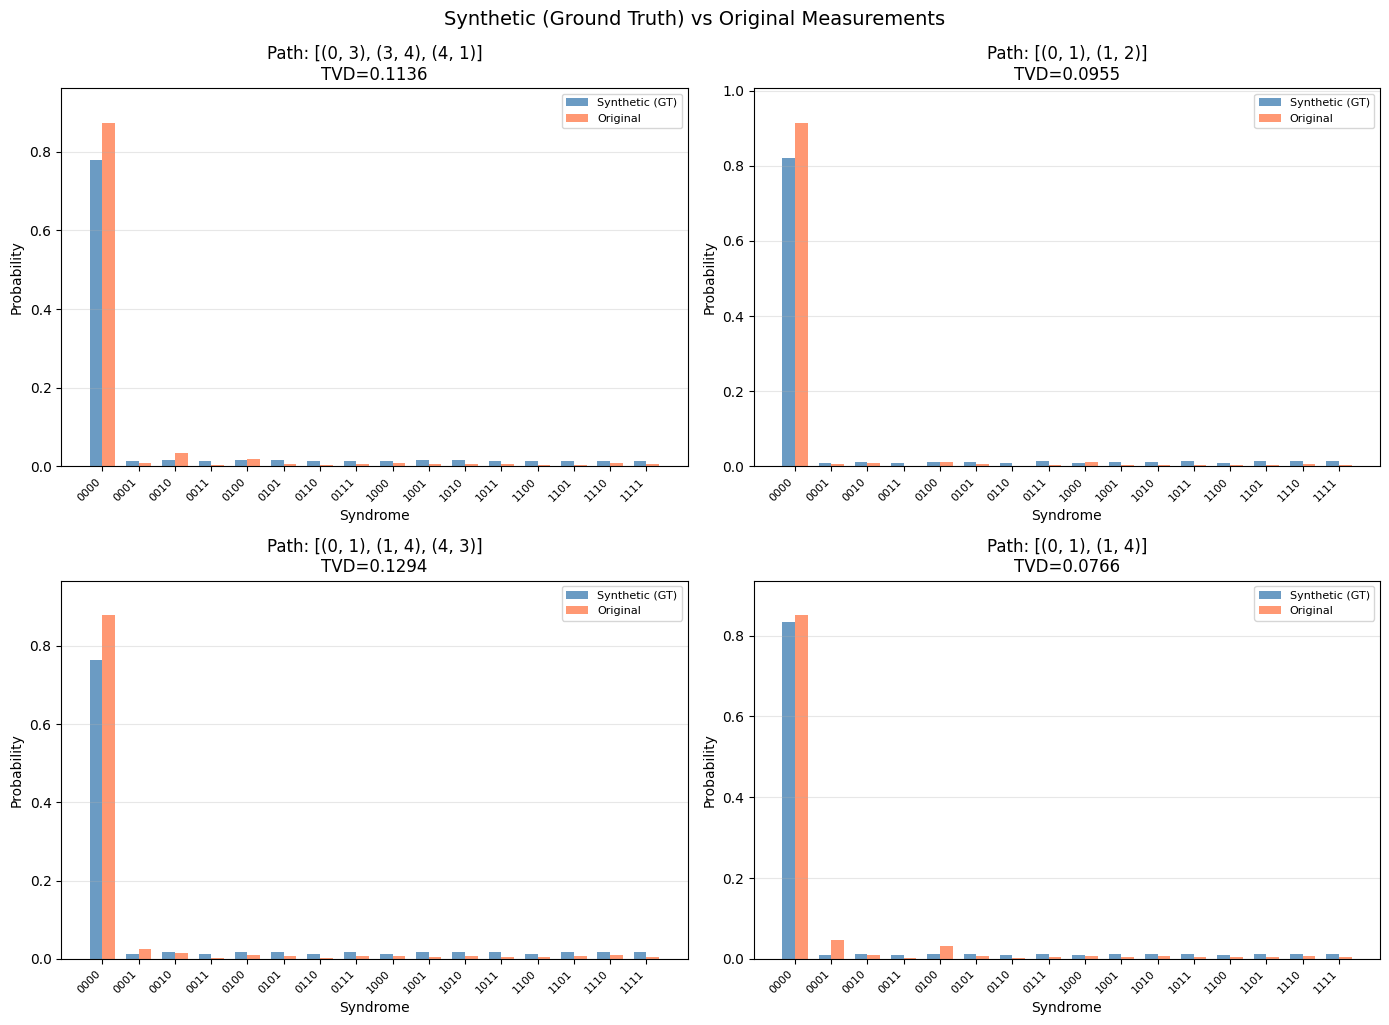

In [8]:
# ============================================================
# VISUALIZE COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# Select sample paths
sample_indices = list(range(min(4, len(measurements))))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(16)
width = 0.35

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    
    orig = measurements[idx]
    synth = synthetic_measurements[idx]
    
    orig_probs = orig.histogram / np.sum(orig.histogram)
    synth_probs = synth.histogram / np.sum(synth.histogram)
    
    bars1 = ax.bar(x - width/2, synth_probs, width, label='Synthetic (GT)', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, orig_probs, width, label='Original', color='coral', alpha=0.8)
    
    tvd = 0.5 * np.sum(np.abs(orig_probs - synth_probs))
    
    ax.set_xlabel('Syndrome')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {orig.path_edges}\nTVD={tvd:.4f}')
    ax.set_xticks(x)
    ax.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(max(synth_probs), max(orig_probs)) * 1.1)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('Synthetic (Ground Truth) vs Original Measurements', fontsize=14, y=1.02)
plt.show()

In [9]:
# ============================================================
# SAVE SYNTHETIC MEASUREMENTS
# ============================================================

with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(synthetic_measurements, f)

print(f"Saved {len(synthetic_measurements)} synthetic measurements to:")
print(f"  {OUTPUT_FILE}")

# Verify by loading back
with open(OUTPUT_FILE, 'rb') as f:
    loaded = pickle.load(f)
print(f"\nVerification: Loaded {len(loaded)} measurements from saved file.")

Saved 24 synthetic measurements to:
  ../syndrome_data_513_2x3/synthetic_measurements.pkl

Verification: Loaded 24 measurements from saved file.


In [10]:
# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("SYNTHETIC MEASUREMENT GENERATION SUMMARY")
print("=" * 60)
print(f"\nInput files:")
print(f"  - Measurements: {MEASUREMENTS_FILE}")
print(f"  - Graph: {GRAPH_FILE}")
print(f"  - Ground Truth: {GROUND_TRUTH_FILE}")

print(f"\nOutput:")
print(f"  - Synthetic measurements: {OUTPUT_FILE}")

print(f"\nStatistics:")
print(f"  - Total measurements: {len(synthetic_measurements)}")
print(f"  - Mean P(0000): {np.mean([m.histogram[0]/np.sum(m.histogram) for m in synthetic_measurements]):.4f}")
print(f"  - Mean TVD vs original: {df_comparison['TVD'].mean():.4f}")

print(f"\nGround truth edges: {list(ground_truth_normalized.keys())}")
print(f"Unique paths: {len(set([str(m.path_edges) for m in synthetic_measurements]))}")

SYNTHETIC MEASUREMENT GENERATION SUMMARY

Input files:
  - Measurements: ../syndrome_data_513_2x3/measurements.pkl
  - Graph: ../syndrome_data_513_2x3/graph.pkl
  - Ground Truth: ../syndrome_data_513_2x3/ground_truth.pkl

Output:
  - Synthetic measurements: ../syndrome_data_513_2x3/synthetic_measurements.pkl

Statistics:
  - Total measurements: 24
  - Mean P(0000): 0.7250
  - Mean TVD vs original: 0.1681

Ground truth edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]
Unique paths: 24
